## Postprocessing and Analysis of Monte Carlo Results

In this notebook, we analyze the Monte Carlo simulation results obtained from the three reconstruction strategies:

* DG-based SIAC filtering applied post-FBP  (`dg`)
* Fourier-domain SIAC filtering applied post-FBP (`fourier`)
* Detector-domain SIAC filtering applied pre-FBP (`detector`)

The raw simulation outputs have been precomputed and stored as CSV files. Each row corresponds to a single Monte Carlo realization for a given noise level and parameter configuration, including:

* reconstruction parameters (e.g. polynomial degree (p), number of moments, B-spline order),
* noise level and random seed,
* quantitative evaluation metrics:

  * relative ($L^2$) error,
  * masked relative ($L^2$) error,
  * gradient-weighted SSIM,
  * SSIM.

The purpose of this notebook is to:

1. Load and unify the results from all methods into a single dataset.
2. Compute summary statistics (mean, standard deviation, etc.) over Monte Carlo repetitions.
3. Identify optimal parameter configurations for each method as a function of noise level.
4. Compare reconstruction performance across methods using multiple metrics.
5. Visualize trends, parameter sensitivity, and robustness.

This separation between simulation and analysis ensures reproducibility, simplifies experimentation, and enables flexible exploration of the results without rerunning computationally expensive simulations.


In [17]:
import numpy as np
import pandas as pd

import sys
sys.path.append("../..")

from src.metrics import(
    summarize_mc_results, 
    select_best_by_noise, 
    select_fixed_params_from_reference_noise, 
    filter_summary_by_fixed_params, 
    display_fixed_params
)
from src.plotting_helpers import (
    display_best_params, 
    plot_mc_metric, 
    plot_selected_param_vs_noise, 
    plot_param_heatmap, 
    compare_fixed_vs_retuned
)

In [18]:
# Read result files
results_dg = pd.read_csv("results_dg.csv")
results_fourier = pd.read_csv("results_fourier.csv")
results_detector = pd.read_csv("results_detector.csv")
results_ramlak = pd.read_csv("results_ramlak.csv")
results_hann = pd.read_csv("results_hann.csv")

# Columns you want available everywhere
common_cols = [
    "method", "noise_level", "rep", "seed",
    "p", "moments", "BSorder",
    "rel_l2_err", "masked_rel_l2_err", "gw_ssim", "ssim"
]

# Helper: add missing columns as NaN, then reorder
def align_columns(df, common_cols):
    df = df.copy()
    for col in common_cols:
        if col not in df.columns:
            df[col] = np.nan
    return df[common_cols]

results_dg = align_columns(results_dg, common_cols)
results_fourier = align_columns(results_fourier, common_cols)
results_detector = align_columns(results_detector, common_cols)
results_ramlak = align_columns(results_ramlak, common_cols)
results_hann = align_columns(results_hann, common_cols)

# Combine into one dataframe
results_all = pd.concat(
    [
        results_dg,
        results_fourier,
        results_detector,
        results_ramlak,
        results_hann,
    ],
    ignore_index=True
)

# Adjust moments: stored value -> true reproduced moments (+1)
if "moments" in results_all.columns:
    mask = results_all["moments"].notna()
    results_all.loc[mask, "moments"] = results_all.loc[mask, "moments"] + 1

# Adjust these names to match exactly what appears in results_all["method"]
family_map = {
    "fbp_ramlak": "FBP",
    "fbp_hann": "FBP",
    "post_recon_dg_siac": "SIAC",
    "post_recon_fourier_siac": "SIAC",
    "pre_recon_detector_siac": "SIAC",
}

results_all["family"] = results_all["method"].map(family_map)

# Quick sanity checks
print("Shape of combined dataframe:", results_all.shape)

print("\nMethods:")
print(results_all["method"].value_counts())

print("\nUnique method names:")
print(results_all["method"].unique())

print("\nMissing values:")
print(results_all.isna().sum())

print("\nFamily counts:")
print(results_all["family"].value_counts(dropna=False))

Shape of combined dataframe: (18760, 12)

Methods:
method
pre_recon_detector_siac    10920
post_recon_dg_siac          4480
post_recon_fourier_siac     2800
fbp_ramlak                   280
fbp_hann                     280
Name: count, dtype: int64

Unique method names:
['post_recon_dg_siac' 'post_recon_fourier_siac' 'pre_recon_detector_siac'
 'fbp_ramlak' 'fbp_hann']

Missing values:
method                   0
noise_level              0
rep                      0
seed                     0
p                    14280
moments                560
BSorder                560
rel_l2_err               0
masked_rel_l2_err        0
gw_ssim                  0
ssim                     0
family                   0
dtype: int64

Family counts:
family
SIAC    18200
FBP       560
Name: count, dtype: int64


In [19]:
summary_all = summarize_mc_results(
    results_all,
    metric_cols=["rel_l2_err", "masked_rel_l2_err", "gw_ssim", "ssim"]
)

summary_all.head(5)

,family,method,noise_level,p,moments,BSorder,rel_l2_err_mean,rel_l2_err_std,rel_l2_err_min,rel_l2_err_max,...,masked_rel_l2_err_min,masked_rel_l2_err_max,gw_ssim_mean,gw_ssim_std,gw_ssim_min,gw_ssim_max,ssim_mean,ssim_std,ssim_min,ssim_max
0,FBP,fbp_hann,0.01,NaN,NaN,NaN,0.319395,0.000210,0.318970,0.319782,...,0.312225,0.313171,0.868412,0.000234,0.867982,0.868959,0.736956,0.000893,0.735536,0.738761
1,FBP,fbp_hann,0.02,NaN,NaN,NaN,0.321522,0.000414,0.320698,0.322276,...,0.312833,0.314724,0.866842,0.000479,0.865940,0.867967,0.711052,0.001627,0.708412,0.714491
2,FBP,fbp_hann,0.03,NaN,NaN,NaN,0.325036,0.000614,0.323841,0.326131,...,0.314215,0.317045,0.864300,0.000734,0.862884,0.866022,0.674279,0.002161,0.670825,0.678959
3,FBP,fbp_hann,0.04,NaN,NaN,NaN,0.329892,0.000808,0.328360,0.331300,...,0.316360,0.320116,0.860881,0.000996,0.858914,0.863212,0.632648,0.002497,0.628867,0.638114
4,FBP,fbp_hann,0.05,NaN,NaN,NaN,0.336031,0.000997,0.334198,0.337722,...,0.319253,0.323916,0.856696,0.001263,0.854146,0.859632,0.590796,0.002660,0.586919,0.596645


,family,method,noise_level,p,moments,BSorder,rel_l2_err_mean,rel_l2_err_std
0,SIAC,post_recon_dg_siac,0.01,1.0,5.0,1.0,0.327293,0.000192
1,SIAC,post_recon_dg_siac,0.02,1.0,5.0,1.0,0.330449,0.000388
2,SIAC,post_recon_dg_siac,0.03,1.0,5.0,1.0,0.335656,0.000599
3,SIAC,post_recon_dg_siac,0.04,1.0,5.0,1.0,0.342823,0.000832
4,SIAC,post_recon_dg_siac,0.05,1.0,5.0,1.0,0.351829,0.001091
5,SIAC,post_recon_dg_siac,0.06,1.0,5.0,1.0,0.362537,0.001375
6,SIAC,post_recon_dg_siac,0.07,1.0,5.0,1.0,0.374801,0.001685
7,SIAC,post_recon_dg_siac,0.08,1.0,3.0,1.0,0.387305,0.001865
8,SIAC,post_recon_dg_siac,0.09,1.0,5.0,2.0,0.398668,0.001773
9,SIAC,post_recon_dg_siac,0.10,1.0,5.0,2.0,0.409593,0.002028


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best relative $L^2$ error vs noise level'}, xlabel='Noise level', ylabel='Relative $L^2$ error'>)

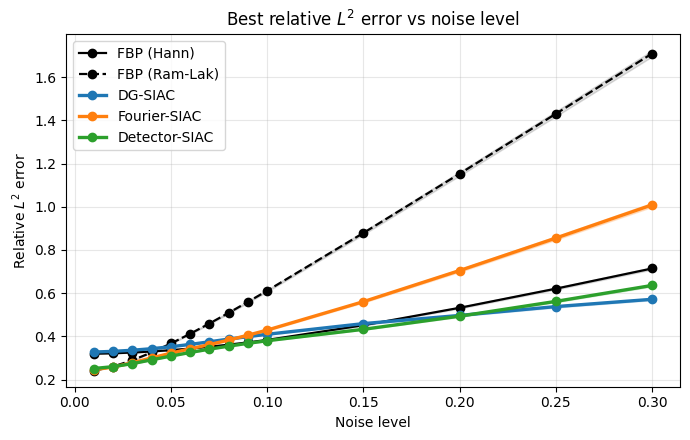

In [20]:
best_rel_l2 = select_best_by_noise(
    summary_all,
    metric="rel_l2_err",
    minimize=True,
)

display_best_params(best_rel_l2, metric="rel_l2_err")

plot_mc_metric(
    best_rel_l2,
    metric="rel_l2_err",
    title="Best relative $L^2$ error vs noise level",
    ylabel="Relative $L^2$ error",
    style_cols=[],
)

,family,method,noise_level,p,moments,BSorder,masked_rel_l2_err_mean,masked_rel_l2_err_std
0,SIAC,post_recon_dg_siac,0.01,1.0,5.0,1.0,0.320064,0.000184
1,SIAC,post_recon_dg_siac,0.02,1.0,5.0,1.0,0.321798,0.000363
2,SIAC,post_recon_dg_siac,0.03,1.0,5.0,1.0,0.324684,0.000540
3,SIAC,post_recon_dg_siac,0.04,1.0,5.0,1.0,0.328693,0.000719
4,SIAC,post_recon_dg_siac,0.05,1.0,5.0,1.0,0.333783,0.000904
5,SIAC,post_recon_dg_siac,0.06,1.0,5.0,1.0,0.339905,0.001097
6,SIAC,post_recon_dg_siac,0.07,1.0,5.0,1.0,0.347006,0.001300
7,SIAC,post_recon_dg_siac,0.08,1.0,5.0,1.0,0.355027,0.001515
8,SIAC,post_recon_dg_siac,0.09,1.0,5.0,1.0,0.363906,0.001741
9,SIAC,post_recon_dg_siac,0.10,1.0,5.0,1.0,0.373583,0.001979


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best masked relative $L^2$ error vs noise level'}, xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

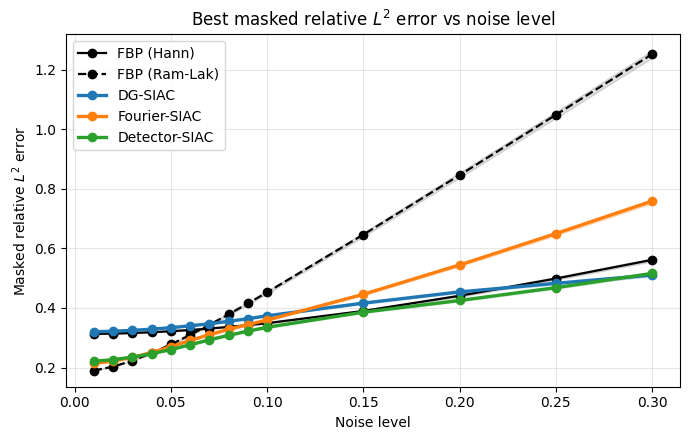

In [21]:
best_masked_rel_l2 = select_best_by_noise(
    summary_all,
    metric="masked_rel_l2_err",
    minimize=True,
)

display_best_params(best_masked_rel_l2, metric="masked_rel_l2_err")

plot_mc_metric(
    best_masked_rel_l2,
    metric="masked_rel_l2_err",
    title="Best masked relative $L^2$ error vs noise level",
    ylabel="Masked relative $L^2$ error",
    style_cols=[],
)

,family,method,noise_level,p,moments,BSorder,gw_ssim_mean,gw_ssim_std
0,SIAC,post_recon_dg_siac,0.01,1.0,5.0,1.0,0.869635,0.000209
1,SIAC,post_recon_dg_siac,0.02,1.0,5.0,1.0,0.867384,0.000432
2,SIAC,post_recon_dg_siac,0.03,1.0,5.0,1.0,0.863751,0.000673
3,SIAC,post_recon_dg_siac,0.04,1.0,5.0,1.0,0.858922,0.000932
4,SIAC,post_recon_dg_siac,0.05,1.0,5.0,1.0,0.853095,0.001204
5,SIAC,post_recon_dg_siac,0.06,1.0,5.0,1.0,0.846455,0.001488
6,SIAC,post_recon_dg_siac,0.07,1.0,5.0,1.0,0.839166,0.001779
7,SIAC,post_recon_dg_siac,0.08,1.0,5.0,1.0,0.831366,0.002077
8,SIAC,post_recon_dg_siac,0.09,1.0,5.0,1.0,0.823173,0.002376
9,SIAC,post_recon_dg_siac,0.10,1.0,5.0,1.0,0.814681,0.002676


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best gradient-weighted SSIM vs noise level'}, xlabel='Noise level', ylabel='Gradient-weighted SSIM'>)

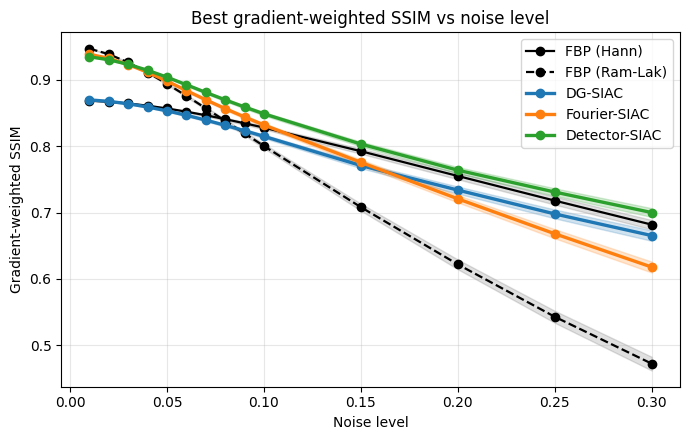

In [22]:
best_gw_ssim = select_best_by_noise(
    summary_all,
    metric="gw_ssim",
    minimize=False,
)

display_best_params(best_gw_ssim, metric="gw_ssim")

plot_mc_metric(
    best_gw_ssim,
    metric="gw_ssim",
    title="Best gradient-weighted SSIM vs noise level",
    ylabel="Gradient-weighted SSIM",
    style_cols=[],
)

,family,method,noise_level,p,moments,BSorder,ssim_mean,ssim_std
0,SIAC,post_recon_dg_siac,0.01,1.0,3.0,3.0,0.758623,0.001941
1,SIAC,post_recon_dg_siac,0.02,1.0,3.0,4.0,0.740266,0.003871
2,SIAC,post_recon_dg_siac,0.03,1.0,3.0,4.0,0.715826,0.005492
3,SIAC,post_recon_dg_siac,0.04,1.0,3.0,4.0,0.685810,0.006649
4,SIAC,post_recon_dg_siac,0.05,1.0,3.0,4.0,0.652879,0.007337
5,SIAC,post_recon_dg_siac,0.06,1.0,3.0,4.0,0.619206,0.007635
6,SIAC,post_recon_dg_siac,0.07,3.0,3.0,2.0,0.590882,0.009828
7,SIAC,post_recon_dg_siac,0.08,3.0,3.0,2.0,0.572684,0.010205
8,SIAC,post_recon_dg_siac,0.09,3.0,3.0,2.0,0.554393,0.010390
9,SIAC,post_recon_dg_siac,0.10,3.0,3.0,3.0,0.536973,0.011584


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best SSIM vs noise level'}, xlabel='Noise level', ylabel='SSIM'>)

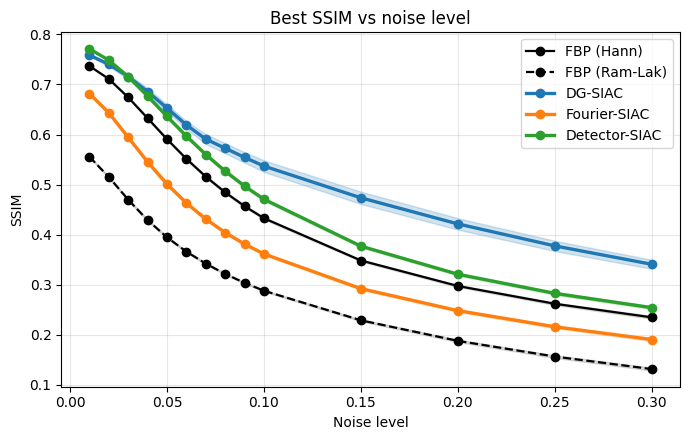

In [23]:
best_ssim = select_best_by_noise(
    summary_all,
    metric="ssim",
    minimize=False,
)

display_best_params(best_ssim, metric="ssim")

plot_mc_metric(
    best_ssim,
    metric="ssim",
    title="Best SSIM vs noise level",
    ylabel="SSIM",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Selected DG degree vs noise level'}, xlabel='Noise level', ylabel='DG degree'>)

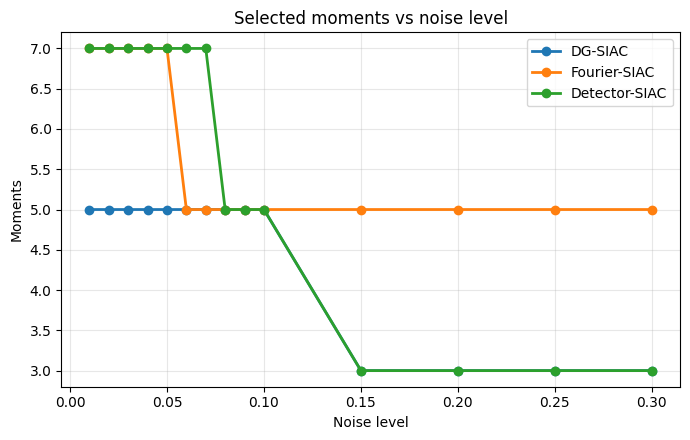

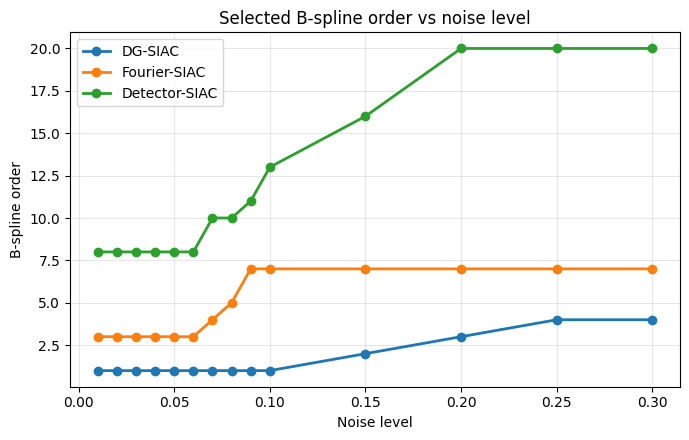

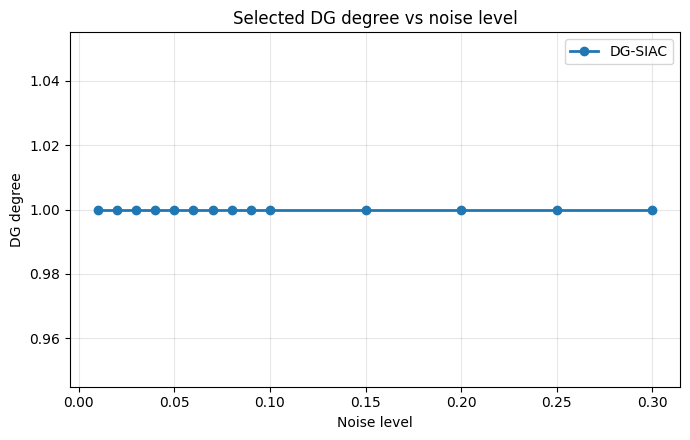

In [24]:
plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="moments",
    title="Selected moments vs noise level",
    ylabel="Moments",
)

plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="BSorder",
    title="Selected B-spline order vs noise level",
    ylabel="B-spline order",
)

plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="p",
    title="Selected DG degree vs noise level",
    ylabel="DG degree",
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'DG (p=1): masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

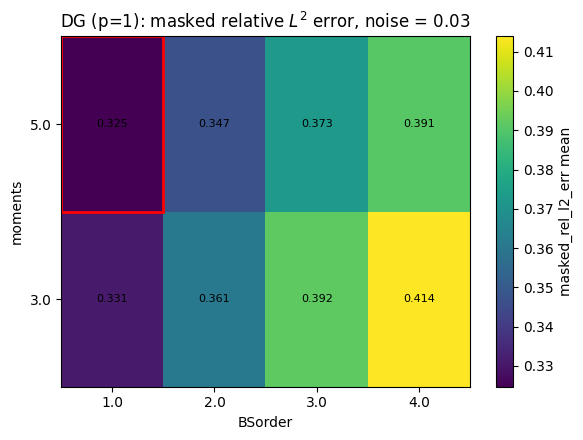

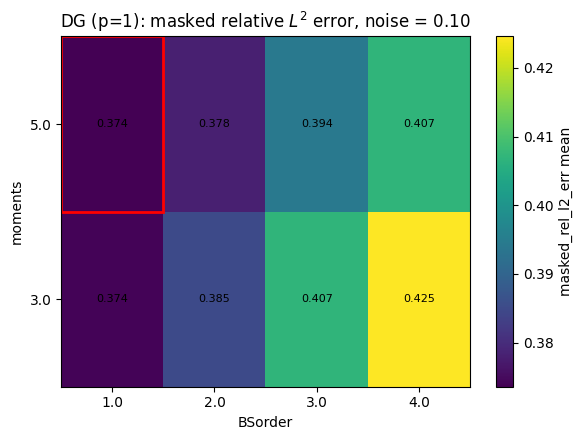

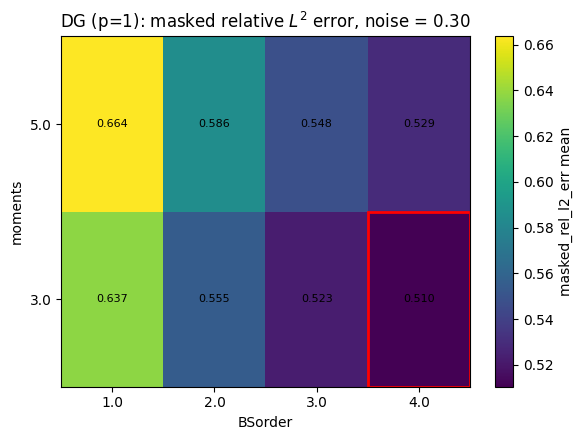

In [25]:
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.03",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.10",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'DG (p=3): masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

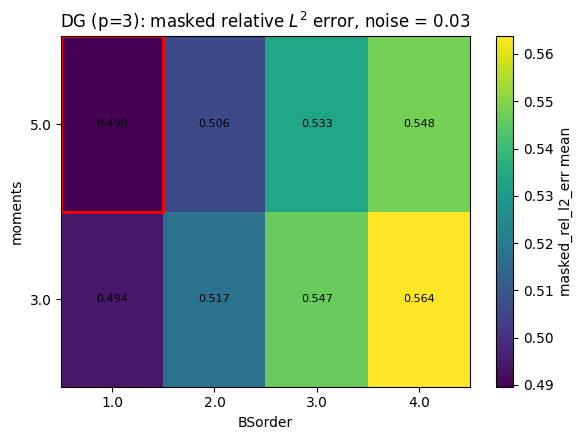

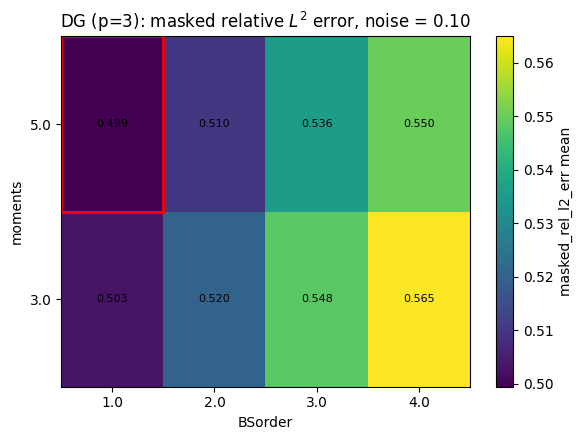

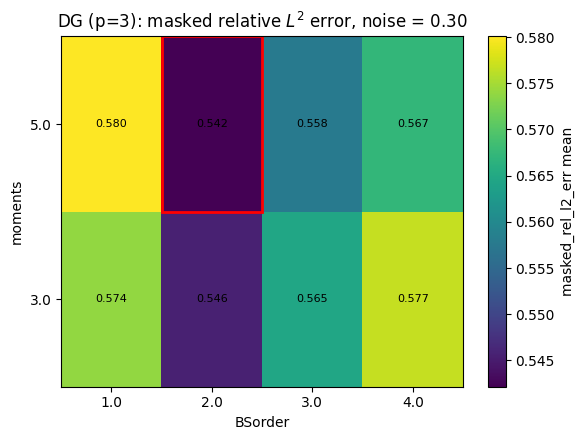

In [26]:
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    fixed_filters={"p": 3},
    title="DG (p=3): masked relative $L^2$ error, noise = 0.03",
    minimize=True
)

plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    fixed_filters={"p": 3},
    title="DG (p=3): masked relative $L^2$ error, noise = 0.10",
    minimize=True
)

plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    fixed_filters={"p": 3},
    title="DG (p=3): masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'Fourier: masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

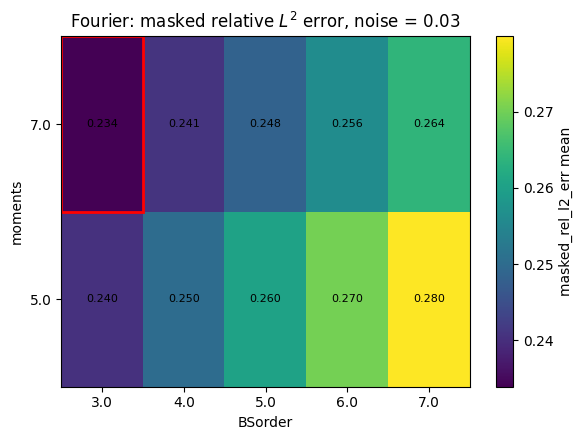

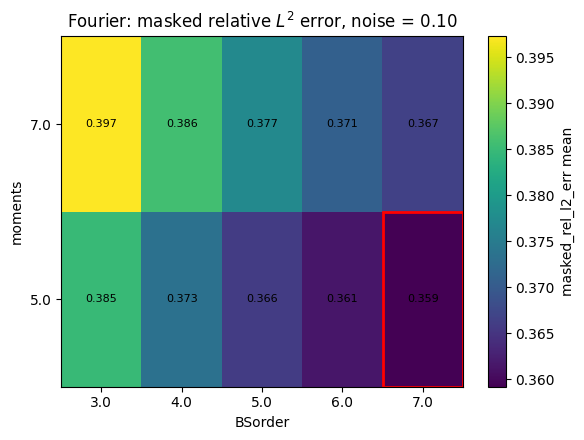

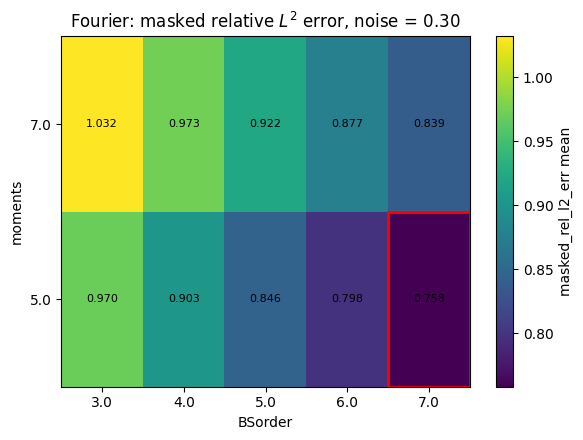

In [27]:
plot_param_heatmap(
    summary_all,
    method="post_recon_fourier_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    title="Fourier: masked relative $L^2$ error, noise = 0.03",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_fourier_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    title="Fourier: masked relative $L^2$ error, noise = 0.10",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_fourier_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    title="Fourier: masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'Detector: masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

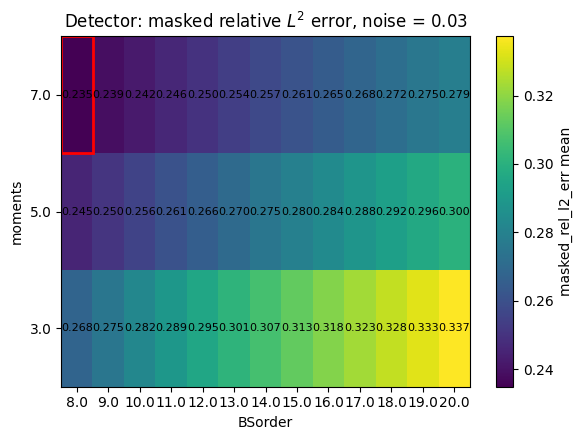

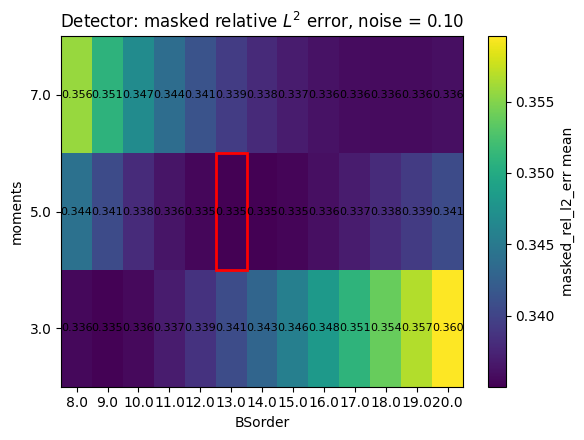

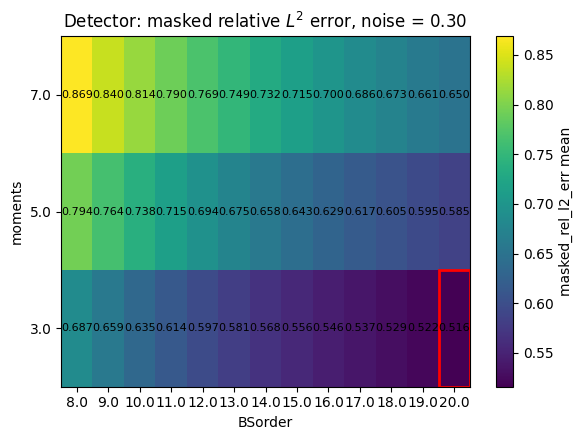

In [28]:
plot_param_heatmap(
    summary_all,
    method="pre_recon_detector_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    title="Detector: masked relative $L^2$ error, noise = 0.03",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="pre_recon_detector_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    title="Detector: masked relative $L^2$ error, noise = 0.10",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="pre_recon_detector_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    title="Detector: masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

In [29]:
fixed_params_10_masked = select_fixed_params_from_reference_noise(
    summary_all,
    metric="masked_rel_l2_err",
    reference_noise=0.10,
    minimize=True,
)

display_fixed_params(
    fixed_params_10_masked,
    metric="masked_rel_l2_err",
)

fixed_curves_10_masked = filter_summary_by_fixed_params(
    summary_all,
    fixed_params_10_masked,
)

,family,method,p,moments,BSorder,masked_rel_l2_err_mean,masked_rel_l2_err_std
0,SIAC,post_recon_dg_siac,1.0,5.0,1.0,0.373583,0.001979
1,SIAC,post_recon_fourier_siac,NaN,5.0,7.0,0.359183,0.002654
2,SIAC,pre_recon_detector_siac,NaN,5.0,13.0,0.335035,0.002878


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Fixed parameters chosen at 10% noise: masked relative $L^2$ vs noise level'}, xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

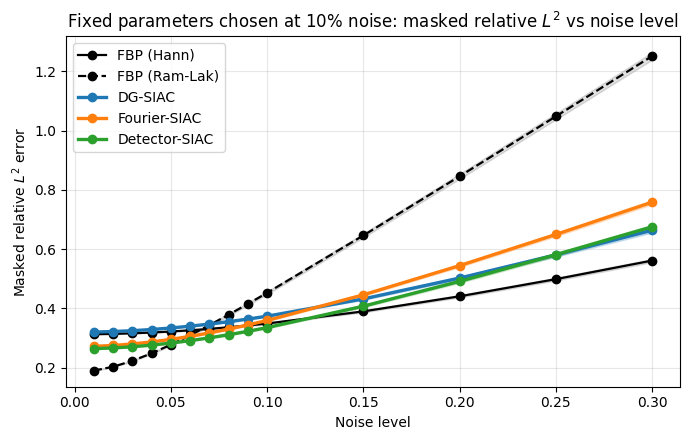

In [30]:
plot_mc_metric(
    fixed_curves_10_masked,
    metric="masked_rel_l2_err",
    title="Fixed parameters chosen at 10% noise: masked relative $L^2$ vs noise level",
    ylabel="Masked relative $L^2$ error",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Fixed parameters chosen at 10% noise: SSIM vs noise level'}, xlabel='Noise level', ylabel='SSIM'>)

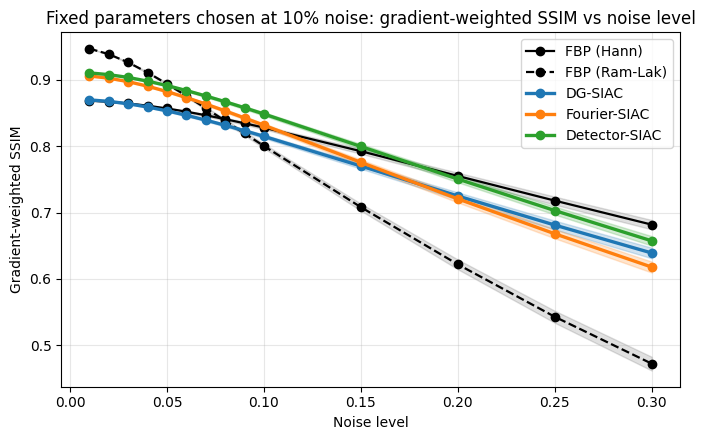

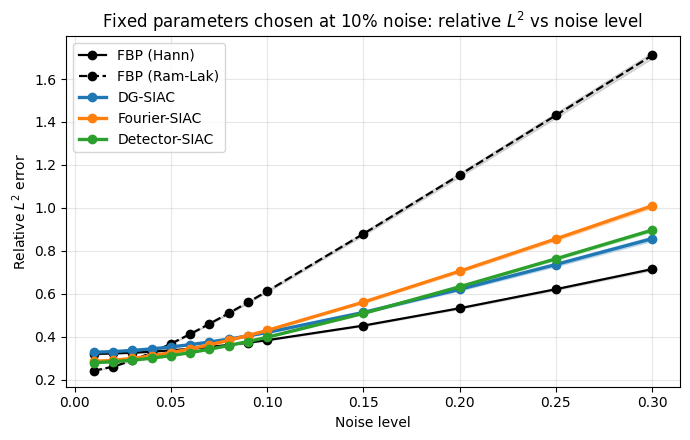

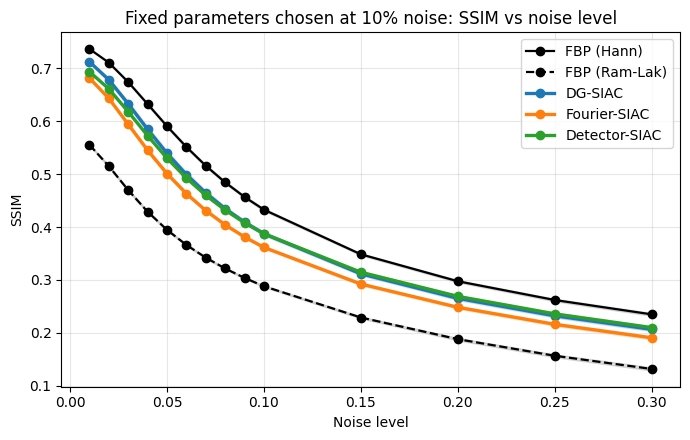

In [31]:
plot_mc_metric(
    fixed_curves_10_masked,
    metric="gw_ssim",
    title="Fixed parameters chosen at 10% noise: gradient-weighted SSIM vs noise level",
    ylabel="Gradient-weighted SSIM",
    style_cols=[],
)

plot_mc_metric(
    fixed_curves_10_masked,
    metric="rel_l2_err",
    title="Fixed parameters chosen at 10% noise: relative $L^2$ vs noise level",
    ylabel="Relative $L^2$ error",
    style_cols=[],
)


plot_mc_metric(
    fixed_curves_10_masked,
    metric="ssim",
    title="Fixed parameters chosen at 10% noise: SSIM vs noise level",
    ylabel="SSIM",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Retuned vs fixed parameters (chosen at 10% noise)'}, xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

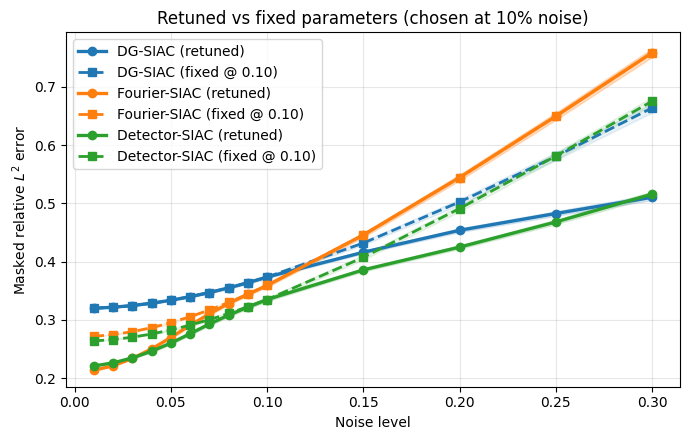

In [32]:
compare_fixed_vs_retuned(
    retuned_df=best_masked_rel_l2,
    fixed_df=fixed_curves_10_masked,
    metric="masked_rel_l2_err",
    title="Retuned vs fixed parameters (chosen at 10% noise)",
    ylabel="Masked relative $L^2$ error",
)